# Agent 365 Random Session Sampling vs Census

This notebook evaluates `random_sampling` on the labeled 300-session Agent 365 OTLP artifact. It compares two deterministic stratified-random seeds against one reused census label pass. There is no MinHash, embedding, novelty score, or diversity slice in this package.

The product-faithful population is built per agent. Because the fixture contains 100 agents and many have only one session, many agent populations become censuses and overall call savings are modest.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT=Path.cwd()
if not (ROOT/'random_sampling').exists(): raise RuntimeError('Run from repository root')
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from random_sampling import DatasetGroundTruthJudge, RunnerConfig, SamplePolicy, load_synthetic_a365_otel, run_policies_vs_census, save_multi_policy_result

DATA=Path(os.environ.get('RANDOM_SAMPLING_DATA_PATH',r'C:\Users\stangoodwin\eval-model-comparison\data\eval-harness\synthetic_observability.a365-otel.json'))
META=DATA.with_name('synthetic_observability.a365-otel.meta.json')
OUT=ROOT/'outputs_random_sampling'; OUT.mkdir(exist_ok=True)
print({'data_exists':DATA.exists(),'metadata_exists':META.exists(),'output_dir':str(OUT)})

{'data_exists': True, 'metadata_exists': True, 'output_dir': 'C:\\Users\\stangoodwin\\singlenotebooks\\outputs_random_sampling'}


## 1. Dataset audit

The source has no explicit session IDs, so each conversation becomes one inactivity-fallback session. Ground-truth Task Completion labels are joined from root `invoke_agent` attributes.

In [2]:
dataset=load_synthetic_a365_otel(DATA)
meta=json.loads(META.read_text(encoding='utf-8'))
rows=[{'tenant_id':u.tenant_id,'agent_id':u.agent_id,'unit_id':u.unit_id,'turns':len(u.turns),'tools':len(u.tool_calls),'expected_pass':dataset.labels_by_unit[u.unit_id or '']} for u in dataset.normalization.units]
units_df=pd.DataFrame(rows)
assert len(units_df)==len(dataset.labels_by_unit)==meta['caseCount']==300
summary={'sessions':len(units_df),'agents':units_df[['tenant_id','agent_id']].drop_duplicates().shape[0],'passes':int(units_df.expected_pass.sum()),'failures':int((~units_df.expected_pass).sum()),'spans':meta['spanCount'],'issues':len(dataset.normalization.issues)}
summary

{'sessions': 300,
 'agents': 100,
 'passes': 188,
 'failures': 112,
 'spans': 2496,
 'issues': 0}

In [3]:
agent_counts=units_df.groupby(['tenant_id','agent_id'],as_index=False).agg(sessions=('unit_id','count'),pass_rate=('expected_pass','mean')).sort_values('sessions',ascending=False)
print(agent_counts.sessions.describe().to_string())
agent_counts.head(15)

count    100.000000
mean       3.000000
std        7.275252
min        1.000000
25%        1.000000
50%        1.000000
75%        1.250000
max       51.000000


,tenant_id,agent_id,sessions,pass_rate
71,badf1f56-284d-4dc5-ac59-0dd53900e743,code-review-copilot,51,0.745098
23,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,notebook-insights-agent,42,0.595238
59,7c1e5a90-2d4b-4f83-b6a1-9e0c3f5a8d21,theorem-prover-assistant,35,0.714286
1,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,benefits-enrollment-agent,7,0.285714
67,badf1f56-284d-4dc5-ac59-0dd53900e743,cad-tolerance-advisor,7,0.571429
54,7c1e5a90-2d4b-4f83-b6a1-9e0c3f5a8d21,press-release-drafter,6,0.500000
41,7c1e5a90-2d4b-4f83-b6a1-9e0c3f5a8d21,deal-desk-assistant,6,0.500000
2,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,campaign-copy-agent,6,0.833333
99,badf1f56-284d-4dc5-ac59-0dd53900e743,vendor-sourcing-agent,6,0.666667
5,3f2a9c14-7b6e-4d21-9a8f-1c5e0b7d4e62,contract-clause-checker,5,0.800000


## 2. Random policies vs census

Both policies use the same Cochran/FPC margin and one reused census judgment set; only the deterministic random seed differs. The selected count and inclusion design are therefore identical, while selected IDs can differ.

In [4]:
policies={'seed_13':SamplePolicy(margin=.10,confidence=.95,seed=13),'seed_29':SamplePolicy(margin=.10,confidence=.95,seed=29)}
result=await run_policies_vs_census(dataset,DatasetGroundTruthJudge(dataset.labels_by_unit),policies,RunnerConfig(max_concurrency=32,max_attempts=1,base_backoff_seconds=0),32768)
artifact=OUT/'ground_truth_random_vs_census.json'
save_multi_policy_result(artifact,result)
print(f'Saved sanitized result: {artifact}')

Saved sanitized result: C:\Users\stangoodwin\singlenotebooks\outputs_random_sampling\ground_truth_random_vs_census.json


In [5]:
summary_rows=[]
for name,arm in result.by_policy.items():
 c=arm.comparison
 summary_rows.append({'policy':name,'population':c['population_total'],'sample_n':c['sampled_units_evaluated'],'census_pass_rate':c['census_pass_rate'],'sample_pass_rate':c['sampled_units_pass_rate'],'signed_error_pp':100*c['signed_error'],'absolute_error_pp':100*c['absolute_error'],'ci_lower':c['sample_ci_lower'],'ci_upper':c['sample_ci_upper'],'census_in_interval':c['census_truth_in_interval'],'calls_saved':c['calls_saved'],'fraction_saved':c['fraction_saved']})
summary_df=pd.DataFrame(summary_rows).sort_values('policy')
summary_df

,policy,population,sample_n,census_pass_rate,sample_pass_rate,signed_error_pp,absolute_error_pp,ci_lower,ci_upper,census_in_interval,calls_saved,fraction_saved
0,seed_13,300,262,0.626667,0.619128,-0.753846,0.753846,0.596318,0.641939,True,38,0.126667
1,seed_29,300,262,0.626667,0.623103,-0.356410,0.356410,0.600213,0.645992,True,38,0.126667


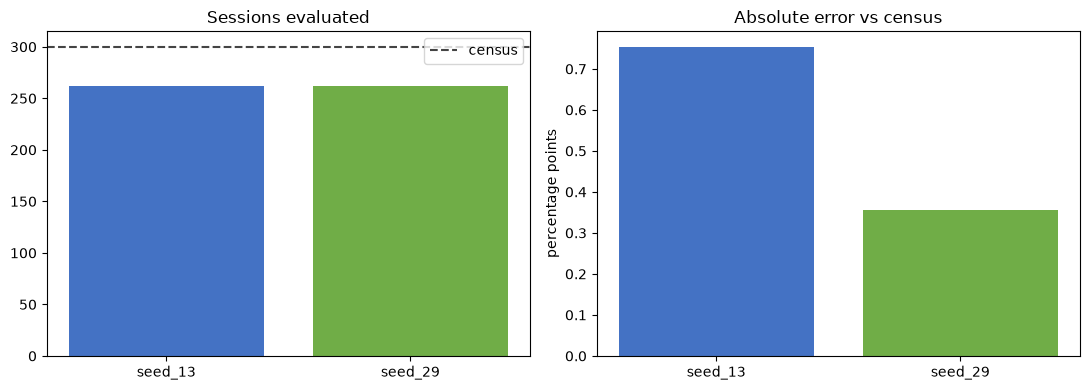

In [6]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
plot=summary_df.set_index('policy')
axes[0].bar(plot.index,plot.sample_n,color=['#4472C4','#70AD47']); axes[0].axhline(300,color='#444',linestyle='--',label='census'); axes[0].set_title('Sessions evaluated'); axes[0].legend()
axes[1].bar(plot.index,plot.absolute_error_pp,color=['#4472C4','#70AD47']); axes[1].set_title('Absolute error vs census'); axes[1].set_ylabel('percentage points')
fig.tight_layout(); plt.show()

## 3. Interpretation

The census rate is exact for the labeled fixture. Each sampled rate is population-weighted across per-agent random samples, with an agent-weighted interval using finite-population corrections. One seed is one realized sample, not a coverage study; repeat many seeds for calibration claims.

Artifacts contain scoped IDs, predictions, aggregate metrics, judge provenance, and no prompts, evidence JSON, credentials, or reasoning.